# Four-Point Probe Resistivity Measurements

Sheet resistance measurements of conductive household materials using a Jandel RM3-AR four-point probe at 9 µA. This notebook loads the experimental data, computes summary statistics, and explores the effects of surface preparation and current direction.

## 1. Setup

In [1]:
import pandas as pd, matplotlib.pyplot as plt, numpy as np, os

LOCAL = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'four_point_probe_readings.csv')
GITHUB = 'https://raw.githubusercontent.com/vivianweidai/research/main/20260404%20Four%20Point%20Probe/OUTPUT/four_point_probe_readings.csv'
SAVE = os.path.exists('IMAGES')

def save(path):
    if SAVE:
        plt.savefig(path, dpi=300, bbox_inches='tight')

df = pd.read_csv(LOCAL) if os.path.exists(LOCAL) else pd.read_csv(GITHUB)

# Filter to valid 9µA readings with actual measurements
valid = df[(df['current_uA'] == 9) & df['sheet_resistance_ohm_per_sq'].notna()].copy()
print(f'Total readings: {len(df)}')
print(f'Valid 9µA readings: {len(valid)}')
print(f'Excluded: {len(df) - len(valid)} (non-conductive, wrong current, or unmeasured)')

Total readings: 65
Valid 9µA readings: 56
Excluded: 9 (non-conductive, wrong current, or unmeasured)


## 2. Summary Statistics

Mean sheet resistance (Ω/□) for each sample, ranked from most to least conductive.

In [2]:
stats = valid.groupby(['sample', 'material'])['sheet_resistance_ohm_per_sq'].agg(
    n='count', mean='mean', std='std', min='min', max='max'
).sort_values('mean').reset_index()

stats['std'] = stats['std'].fillna(0)
stats['mean_str'] = stats['mean'].map('{:.1f}'.format)
stats['std_str'] = stats['std'].map('{:.1f}'.format)
stats['range_str'] = stats.apply(lambda r: f"{r['min']:.1f}–{r['max']:.1f}", axis=1)

print(f"{'Sample':<28} {'Material':<22} {'n':>3}  {'Mean':>6} {'± Std':>6}  {'Range'}")
print('—' * 80)
for _, r in stats.iterrows():
    print(f"{r['sample']:<28} {r['material']:<22} {r['n']:>3}  {r['mean_str']:>6} {('± ' + r['std_str']):>6}  {r['range_str']}")

Sample                       Material                 n    Mean  ± Std  Range
————————————————————————————————————————————————————————————————————————————————
quarter                      nickel-clad copper       2    37.8  ± 0.2  37.6–37.9
stainless steel spoon        stainless steel          7    39.0  ± 1.8  36.6–41.5
penny (unpolished)           copper-plated zinc       3    47.3  ± 2.4  44.5–48.9
aluminum foil                aluminum                 5    48.1  ± 0.4  47.6–48.7
penny (semi-polished)        copper-plated zinc      10    48.6  ± 1.6  46.1–51.8
penny (fully polished)       copper-plated zinc      16    50.1  ± 2.5  47.5–55.7
aluminum foil (flipped)      aluminum                 3    54.7  ± 1.8  52.8–56.2
metal washer                 steel                    5    54.8  ± 1.2  53.2–56.2
house key                    brass                    5    57.2  ± 1.0  56.1–58.3


## 3. Mean Sheet Resistance by Sample

Horizontal bar chart comparing all conductive samples. Lower values = more conductive.

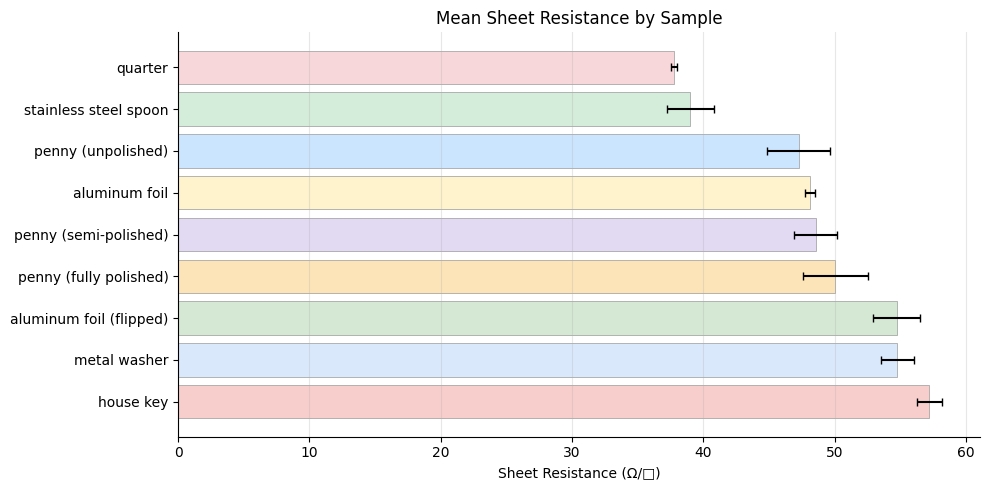

In [3]:
COLORS = ['#f8d7da', '#d4edda', '#cce5ff', '#fff3cd', '#e2d9f3',
          '#fce4b8', '#d5e8d4', '#dae8fc', '#f8cecc', '#e1d5e7']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(stats['sample'], stats['mean'], xerr=stats['std'],
               color=COLORS[:len(stats)], capsize=3, edgecolor='#999', linewidth=0.5)
ax.set_xlabel('Sheet Resistance (Ω/□)')
ax.set_title('Mean Sheet Resistance by Sample')
ax.invert_yaxis()
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
save('IMAGES/mean_sheet_resistance.png')
plt.show()

## 4. Penny Surface Condition

The penny was sanded into three bands — untouched copper, lightly polished, and fully sanded to exposed zinc — then measured in both forward and reverse current directions. This is the most interesting sub-experiment: does polishing change the reading? Does current direction matter?

                           mean   std  count
surface        direction                    
fully polished FWD        52.82  1.85      6
               REV        48.40  0.55     10
semi-polished  FWD        50.69  0.94      3
               REV        47.64  0.72      7
unpolished     REV        47.26  2.41      3


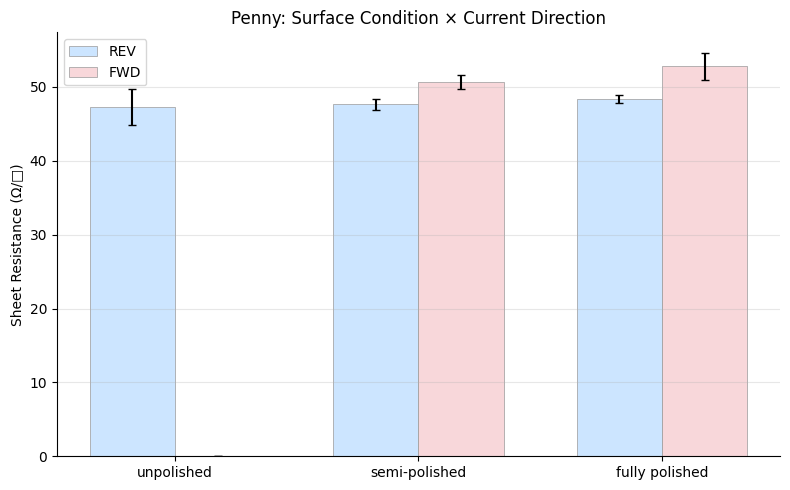

In [4]:
penny = valid[valid['sample'].str.startswith('penny')].copy()
penny['surface'] = penny['sample'].str.extract(r'\((.+?)\)')[0]

# Summary by surface × direction
penny_stats = penny.groupby(['surface', 'direction'])['sheet_resistance_ohm_per_sq'].agg(
    ['mean', 'std', 'count']
).round(2)
print(penny_stats.to_string())

# Grouped bar chart
surfaces = ['unpolished', 'semi-polished', 'fully polished']
dirs = ['REV', 'FWD']
dir_colors = ['#cce5ff', '#f8d7da']
x = np.arange(len(surfaces))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
for i, d in enumerate(dirs):
    means = [penny[(penny['surface'] == s) & (penny['direction'] == d)]['sheet_resistance_ohm_per_sq'].mean()
             for s in surfaces]
    stds = [penny[(penny['surface'] == s) & (penny['direction'] == d)]['sheet_resistance_ohm_per_sq'].std()
            for s in surfaces]
    # Replace NaN with 0 for surfaces with no readings in that direction
    means = [m if not np.isnan(m) else 0 for m in means]
    stds = [s if not np.isnan(s) else 0 for s in stds]
    ax.bar(x + i*w, means, w, yerr=stds, label=d, color=dir_colors[i],
           capsize=3, edgecolor='#999', linewidth=0.5)

ax.set_xticks(x + w/2)
ax.set_xticklabels(surfaces)
ax.set_ylabel('Sheet Resistance (Ω/□)')
ax.set_title('Penny: Surface Condition × Current Direction')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
save('IMAGES/penny_surface_direction.png')
plt.show()

## 5. Current Direction Effect

For samples measured in both forward and reverse current, compare the means. A systematic offset would suggest contact asymmetry or thermoelectric effects at the probe tips.

Sample                           FWD     REV    Diff
————————————————————————————————————————————————————
aluminum foil                  48.00   48.30   -0.31
house key                      57.80   56.30   +1.50
penny (semi-polished)          50.69   47.64   +3.05
penny (fully polished)         52.82   48.40   +4.42

Mean FWD-REV offset: +2.16 Ω/□


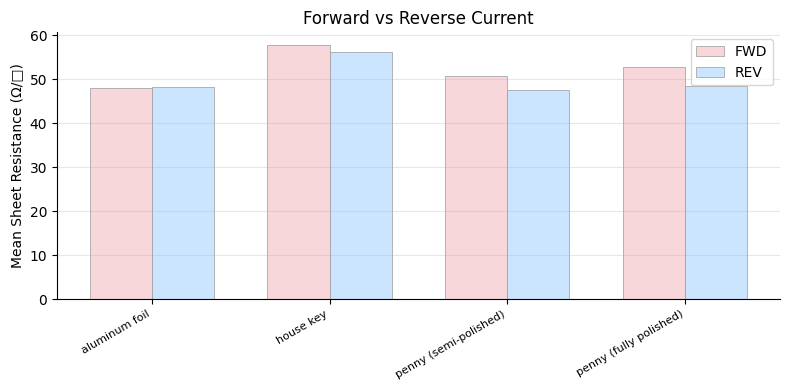

In [5]:
# Samples with both FWD and REV readings
both = valid.groupby('sample').filter(lambda g: set(g['direction']) == {'FWD', 'REV'})
dir_stats = both.groupby(['sample', 'direction'])['sheet_resistance_ohm_per_sq'].mean().unstack()
dir_stats['diff'] = dir_stats['FWD'] - dir_stats['REV']
dir_stats = dir_stats.sort_values('diff')

print(f"{'Sample':<28} {'FWD':>7} {'REV':>7} {'Diff':>7}")
print('—' * 52)
for sample, row in dir_stats.iterrows():
    print(f"{sample:<28} {row['FWD']:>7.2f} {row['REV']:>7.2f} {row['diff']:>+7.2f}")
print(f"\nMean FWD-REV offset: {dir_stats['diff'].mean():+.2f} Ω/□")

fig, ax = plt.subplots(figsize=(8, 4))
samples = dir_stats.index.tolist()
x = np.arange(len(samples))
w = 0.35
ax.bar(x, dir_stats['FWD'], w, label='FWD', color='#f8d7da', edgecolor='#999', linewidth=0.5)
ax.bar(x + w, dir_stats['REV'], w, label='REV', color='#cce5ff', edgecolor='#999', linewidth=0.5)
ax.set_xticks(x + w/2)
ax.set_xticklabels(samples, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Mean Sheet Resistance (Ω/□)')
ax.set_title('Forward vs Reverse Current')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
save('IMAGES/fwd_vs_rev.png')
plt.show()

## 6. Aluminum Foil — Orientation Effect

The foil was flipped upside down mid-experiment to test whether the two sides have different surface resistance (e.g., matte vs shiny side).

              mean   std  count
orientation                    
flipped      54.71  1.78      3
normal       48.12  0.38      5


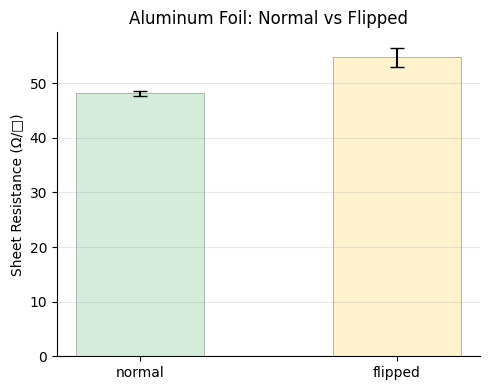

In [6]:
foil = valid[valid['sample'].str.startswith('aluminum')].copy()
foil['orientation'] = foil['sample'].apply(lambda x: 'flipped' if 'flipped' in x else 'normal')

foil_stats = foil.groupby('orientation')['sheet_resistance_ohm_per_sq'].agg(['mean', 'std', 'count'])
print(foil_stats.round(2).to_string())

fig, ax = plt.subplots(figsize=(5, 4))
orientations = ['normal', 'flipped']
means = [foil_stats.loc[o, 'mean'] for o in orientations]
stds = [foil_stats.loc[o, 'std'] for o in orientations]
ax.bar(orientations, means, yerr=stds, color=['#d4edda', '#fff3cd'],
       capsize=5, edgecolor='#999', linewidth=0.5, width=0.5)
ax.set_ylabel('Sheet Resistance (Ω/□)')
ax.set_title('Aluminum Foil: Normal vs Flipped')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
save('IMAGES/foil_orientation.png')
plt.show()

---

<a href="https://colab.research.google.com/github/vivianweidai/research/blob/main/20260404%20Four%20Point%20Probe/OUTPUT/four_point_probe_analysis.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align:middle;"></a>